<a href="https://colab.research.google.com/github/Chaitanyakrishna294/SST_reconstruction/blob/main/SST_Reconstruction_MHW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 SST Reconstruction + Marine Heatwave Detection — Bay of Bengal

## Project Overview
Satellite Sea Surface Temperature (SST) images often contain **missing data patches** caused by cloud cover.
This notebook presents a full pipeline to:

1. **Download** NOAA OISST daily SST data for the Bay of Bengal
2. **Compute coast-distance features** to make models aware of coastal boundaries
3. **Reconstruct missing patches** using two deep learning models:
   - **Coastal-Aware U-Net** — fast, deterministic spatial reconstruction with MC-Dropout uncertainty
   - **Light DDPM** — probabilistic diffusion model for realistic stochastic completions
4. **Detect Marine Heatwaves (MHW)** using the Hobday et al. (2016) climatological threshold method
5. **Forecast future SST** (1–5 days ahead) using a 3D CNN trained on rolling windows

### Key Design Choices
| Component | Choice | Reason |
|-----------|--------|--------|
| Reconstruction | U-Net | Proven encoder-decoder for spatial inpainting |
| Uncertainty | MC-Dropout | Cheap Bayesian approximation at inference |
| Generative | DDPM (cosine schedule) | More realistic textures vs. deterministic output |
| MHW Detection | 90th percentile climatology | Standard oceanographic method (Hobday 2016) |
| Forecasting | 3D CNN | Captures spatiotemporal dynamics efficiently |

**Region:** Bay of Bengal (5°N–23°N, 80°E–100°E)  
**Data:** NOAA OISST v2 High-Resolution (0.25°, daily)  
**Framework:** PyTorch

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────
!pip -q install xarray netCDF4 pandas numpy scipy matplotlib tqdm einops torch torchvision scikit-image scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.9 MB/s eta 0:00:00


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — Imports & Global Config
# ─────────────────────────────────────────────────────────────────────────────
import os, math, json, urllib.request, warnings, datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from scipy.ndimage import distance_transform_edt
from skimage.metrics import structural_similarity as ssim_fn

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── User-tunable hyper-parameters ────────────────────────────────────────────
YEAR_SELECT  = 2019        # Year for MHW analysis & forecasting
FUTURE_DAYS  = 3           # Forecast horizon: 1, 3, or 5
assert FUTURE_DAYS in [1, 3, 5], "FUTURE_DAYS must be 1, 3, or 5"

REGION = dict(lon_min=80.0, lon_max=100.0, lat_min=5.0, lat_max=23.0)  # Bay of Bengal
YEARS  = [2019]            # Years used for model training

# U-Net training
PATCH   = 64
STRIDE  = 32
EPOCHS  = 6
BATCH   = 32
MC_T    = 8               # MC-Dropout passes (increased from 6 for better uncertainty)

# DDPM config — cosine schedule gives smoother diffusion than linear
DDPM_STEPS      = 50
DDPM_EPOCHS     = 4
DDPM_BATCH      = 32
DDPM_BETA_SCHED = 'cosine'   # ← Improved: cosine > linear for SST textures
DDPM_MIN_BETA   = 1e-4
DDPM_MAX_BETA   = 0.02

# Forecaster
FCTX_DAYS = 14
F_EPOCHS  = 3
F_BATCH   = 32

USE_PRESENT_DAY = True
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
DATA_DIR = '/content/data'
FIG_DIR  = '/content/figs'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

print(f"Device: {DEVICE} | Seed: {SEED}")
print(f"Region: Bay of Bengal ({REGION})")
print(f"Training years: {YEARS} | Analysis year: {YEAR_SELECT}")

Device: cuda | Seed: 42
Region: Bay of Bengal ({'lon_min': 80.0, 'lon_max': 100.0, 'lat_min': 5.0, 'lat_max': 23.0})
Training years: [2019] | Analysis year: 2019


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — Data Download & Subsetting
# ─────────────────────────────────────────────────────────────────────────────
# NOAA OISST v2 High-Resolution: 0.25° daily global SST.
# We subset to the Bay of Bengal bounding box defined in REGION.

def fetch_oisst_year(year: int) -> str:
    """Download NOAA OISST NetCDF for a given year if not already cached."""
    url = f"https://downloads.psl.noaa.gov/Datasets/noaa.oisst.v2.highres/sst.day.mean.{year}.nc"
    fn  = f"{DATA_DIR}/oisst_{year}.nc"
    if not os.path.exists(fn):
        print(f"Downloading {year} SST data... (~100MB)")
        urllib.request.urlretrieve(url, fn)
    return fn


def open_subset_year(year: int) -> xr.Dataset:
    """Open and spatially subset the OISST dataset to the Bay of Bengal."""
    fn = fetch_oisst_year(year)
    ds = xr.open_dataset(fn, engine='netcdf4')
    if 'sst' in ds.data_vars:
        ds = ds.rename({'sst': 'SST'})
    ds = ds.sel(
        lat=slice(REGION['lat_min'], REGION['lat_max']),
        lon=slice(REGION['lon_min'], REGION['lon_max'])
    )
    if not np.issubdtype(ds['time'].dtype, np.datetime64):
        ds = xr.decode_cf(ds)
    return ds


# Load training years
ds_list = [open_subset_year(y) for y in YEARS]
ds      = xr.concat(ds_list, dim='time').sortby('time')
print(f"\nDataset loaded — shape (time, lat, lon): {ds['SST'].shape}")
print(f"Time range: {str(ds.time.values[0])[:10]} → {str(ds.time.values[-1])[:10]}")
print(f"SST range: {float(ds['SST'].min()):.2f}°C – {float(ds['SST'].max()):.2f}°C")


Dataset loaded — shape (time, lat, lon): (365, 72, 80)
Time range: 2019-01-01 → 2019-12-31
SST range: 18.63°C – 32.19°C


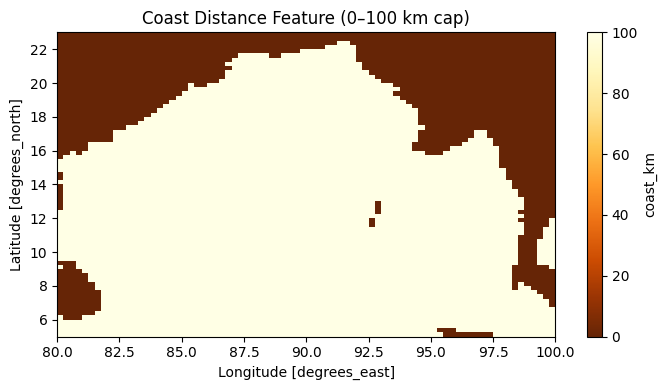

Coast distance feature computed.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — Coast-Distance Feature Engineering
# ─────────────────────────────────────────────────────────────────────────────
# Coastal regions have different SST dynamics (upwelling, river outflow, etc.).
# We compute a 0–100 km distance-to-coast map as an auxiliary input channel
# so the model learns to treat coastal pixels differently from open-ocean ones.

raw_sst  = ds['SST'].astype('float32')
land_mask = np.isnan(raw_sst.values)       # (T, H, W) — NaN = land
land_any  = np.any(land_mask, axis=0)      # (H, W) — True where ANY timestep is land
ocean     = ~land_any

# Euclidean distance transform from ocean pixels toward land
dist_pix  = distance_transform_edt(ocean == 1)

# Convert pixel distance → km using lat/lon grid spacing
lats = ds['lat'].values
lons = ds['lon'].values
dlat_km      = 111.0                                              # ~111 km per degree latitude
dlon_km      = 111.0 * np.cos(np.deg2rad(lats))                  # varies with latitude
dlon_km_grid = np.tile(dlon_km[:, None], (1, len(lons)))
avg_step_km  = np.sqrt((dlat_km**2 + dlon_km_grid**2) / 2.0)    # RMS pixel step in km
dist_km      = np.clip(dist_pix * avg_step_km, 0, 100)           # cap at 100 km

coast_dist = xr.DataArray(
    dist_km,
    coords={'lat': ds['lat'], 'lon': ds['lon']},
    dims=('lat', 'lon'),
    name='coast_km'
)

# Quick sanity plot
plt.figure(figsize=(7, 4))
coast_dist.plot(cmap='YlOrBr_r', vmin=0, vmax=100)
plt.title('Coast Distance Feature (0–100 km cap)')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/coast_distance.png", dpi=150)
plt.show()
print("Coast distance feature computed.")

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — Normalization, Gap Simulation & Patch Extraction
# ─────────────────────────────────────────────────────────────────────────────
# Missing data is simulated by randomly masking 20% of pixels in each patch.
# Patches of size 64×64 are extracted with stride 32 (50% overlap).

arr  = raw_sst.copy().astype('float32').fillna(0.0).clip(min=-2.0, max=35.0)
mu   = float(arr.mean())
sigma = float(arr.std())
arrn = (arr - mu) / (sigma + 1e-6)            # Z-score normalisation
coast01 = (coast_dist / 100.0).clip(0, 1)     # Normalise coast distance to [0, 1]

print(f"SST normalisation: μ={mu:.2f}°C, σ={sigma:.2f}°C")


def extract_patches_with_coast(
    da3d: xr.DataArray,
    coast2d: xr.DataArray,
    patch: int = 64,
    stride: int = 32
):
    """Extract overlapping spatial patches from the SST and coast arrays.

    Returns:
        X      : (N, 1, P, P) float32 — normalised SST patches
        coast  : (N, 1, P, P) float32 — coast-distance patches
        times  : (N,) int — source time index for each patch
    """
    A = da3d.values.astype('float32')     # (T, H, W)
    C = coast2d.values.astype('float32')  # (H, W)
    T, H, W = A.shape
    X, coast, times = [], [], []
    for t in range(T):
        F = A[t]
        for i in range(0, H - patch + 1, stride):
            for j in range(0, W - patch + 1, stride):
                X.append(F[i:i+patch, j:j+patch])
                coast.append(C[i:i+patch, j:j+patch])
                times.append(t)
    X     = np.stack(X)[:, None, ...]     # (N, 1, P, P)
    coast = np.stack(coast)[:, None, ...]  # (N, 1, P, P)
    return X.astype('float32'), coast.astype('float32'), np.array(times)


X_all, C_all, times_idx = extract_patches_with_coast(arrn, coast01, patch=PATCH, stride=STRIDE)

# Simulate missing data: 80% keep probability → 20% missing per patch
rng   = np.random.default_rng(SEED)
M_all = (rng.random(X_all.shape) < 0.8).astype('float32')  # 1 = observed, 0 = missing
Y_all = X_all.copy()          # Ground truth (complete SST)
X_in  = X_all * M_all         # Masked input (0 where missing)

# 70 / 15 / 15 train-val-test split
N    = len(X_in)
perm = rng.permutation(N)
ntr, nva = int(0.70 * N), int(0.85 * N)
tr_idx, va_idx, te_idx = perm[:ntr], perm[ntr:nva], perm[nva:]

Xtr, Mtr, Ctr, Ytr = X_in[tr_idx], M_all[tr_idx], C_all[tr_idx], Y_all[tr_idx]
Xva, Mva, Cva, Yva = X_in[va_idx], M_all[va_idx], C_all[va_idx], Y_all[va_idx]
Xte, Mte, Cte, Yte = X_in[te_idx], M_all[te_idx], C_all[te_idx], Y_all[te_idx]

print(f"Total patches: {N} | Train: {len(Xtr)} | Val: {len(Xva)} | Test: {len(Xte)}")

SST normalisation: μ=20.47°C, σ=13.12°C
Total patches: 365 | Train: 255 | Val: 55 | Test: 55


U-Net parameters: 472,833

Training Coastal-Aware U-Net...
  Epoch 01/6 | train=0.3765 | val=0.5556
  Epoch 02/6 | train=0.1849 | val=0.2990
  Epoch 03/6 | train=0.1647 | val=0.1862
  Epoch 04/6 | train=0.1517 | val=0.1164
  Epoch 05/6 | train=0.1422 | val=0.0990
  Epoch 06/6 | train=0.1412 | val=0.0722
Best val loss: 0.0722


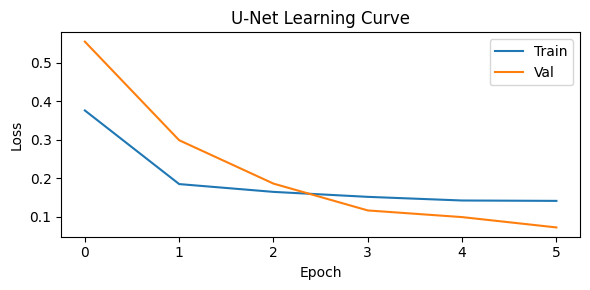

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — Coastal-Aware U-Net Architecture
# ─────────────────────────────────────────────────────────────────────────────
# U-Net uses skip connections to preserve spatial detail.
# Our modification: 3-channel input = [masked SST | mask | coast distance]
# MC-Dropout (kept ON at inference) provides uncertainty estimates.

class ConvBlock(nn.Module):
    """Double convolution block with ReLU and spatial dropout."""
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in,  c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
            nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
            nn.Dropout2d(dropout)
        )
    def forward(self, x):
        return self.conv(x)


class UNetCoastal(nn.Module):
    """
    Coastal-Aware U-Net for SST inpainting.

    Input channels:
        x : masked SST (1 ch)
        m : binary mask — 1=observed, 0=missing (1 ch)
        c : coast distance normalised 0–1 (1 ch)
    Total: 3 input channels → 1 output channel (reconstructed SST)
    """
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3, 32)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.dec3 = ConvBlock(128 + 64, 64)
        self.dec2 = ConvBlock(64 + 32,  32)
        self.outc = nn.Conv2d(32, 1, 1)

    def forward(self, x, m, c):
        z  = torch.cat([x, m, c], dim=1)         # (B, 3, H, W)
        e1 = self.enc1(z)                          # (B, 32, H, W)
        e2 = self.enc2(self.pool(e1))              # (B, 64, H/2, W/2)
        e3 = self.enc3(self.pool(e2))              # (B, 128, H/4, W/4)
        d3 = F.interpolate(e3, scale_factor=2, mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d2 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))
        return self.outc(d2)


model = UNetCoastal().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters: {n_params:,}")


class SSTDataset(Dataset):
    def __init__(self, X, M, C, Y):
        self.X, self.M, self.C, self.Y = X, M, C, Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return (
            torch.from_numpy(self.X[i]),
            torch.from_numpy(self.M[i]),
            torch.from_numpy(self.C[i]),
            torch.from_numpy(self.Y[i])
        )


train_dl = DataLoader(SSTDataset(Xtr, Mtr, Ctr, Ytr), batch_size=BATCH, shuffle=True,  drop_last=False)
val_dl   = DataLoader(SSTDataset(Xva, Mva, Cva, Yva), batch_size=BATCH, shuffle=False, drop_last=False)
test_dl  = DataLoader(SSTDataset(Xte, Mte, Cte, Yte), batch_size=BATCH, shuffle=False)

# Combined L1 + MSE loss: L1 for robustness, MSE to penalise large errors
opt  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)


def run_epoch_unet(dl, train: bool = True) -> float:
    """One training or validation pass for the U-Net."""
    model.train(train)
    total, n = 0.0, 0
    for xb, mb, cb, yb in dl:
        xb, mb, cb, yb = xb.to(DEVICE), mb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
        pred = model(xb, mb, cb)
        loss = F.l1_loss(pred, yb) + 0.2 * F.mse_loss(pred, yb)
        if train:
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            opt.step()
        total += loss.item() * len(xb)
        n     += len(xb)
    return total / max(n, 1)


print("\nTraining Coastal-Aware U-Net...")
train_losses, val_losses = [], []
best, best_w = float('inf'), None
for ep in range(1, EPOCHS + 1):
    tr = run_epoch_unet(train_dl, True)
    va = run_epoch_unet(val_dl,   False)
    sched.step()
    train_losses.append(tr)
    val_losses.append(va)
    print(f"  Epoch {ep:02d}/{EPOCHS} | train={tr:.4f} | val={va:.4f}")
    if va < best:
        best = va
        best_w = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
model.load_state_dict(best_w)
print(f"Best val loss: {best:.4f}")

# Plot learning curves
plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('U-Net Learning Curve')
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/unet_learning_curve.png", dpi=150); plt.show()


U-Net Test Metrics:
  MAE: 0.0776
  RMSE: 0.1587
  GradDiff: 0.0804
  SSIM: 0.8905


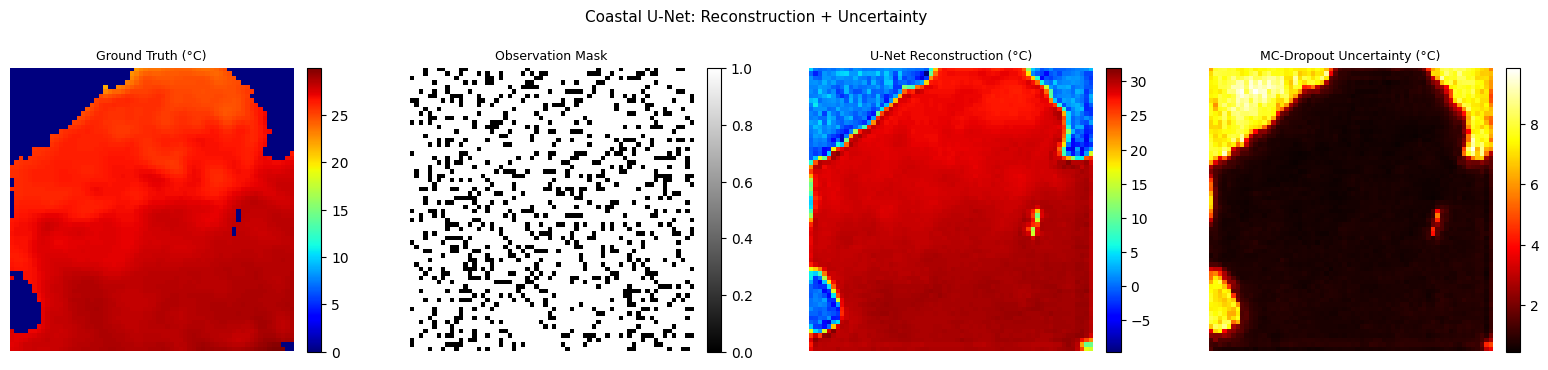

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — U-Net Evaluation with MC-Dropout Uncertainty
# ─────────────────────────────────────────────────────────────────────────────
# MC-Dropout: run the model T times with dropout ACTIVE at inference.
# Mean of T samples = prediction; Std = epistemic uncertainty map.

def gradient_magnitude(z: torch.Tensor) -> torch.Tensor:
    """Compute spatial gradient magnitude for edge-sharpness metric."""
    gx = F.pad(z[..., 1:] - z[..., :-1], (0, 1, 0, 0))
    gy = F.pad(z[:, :, 1:, :] - z[:, :, :-1, :], (0, 0, 0, 1))
    return torch.sqrt(gx**2 + gy**2 + 1e-8)


def denorm(z):
    """Reverse Z-score normalisation to recover °C values."""
    return z * (sigma + 1e-6) + mu


def evaluate_unet(dl, T_mc: int = MC_T):
    """Evaluate U-Net with MC-Dropout; returns MAE, RMSE, Gradient Diff, SSIM."""
    model.train(True)   # Dropout must stay ON for MC sampling
    maes, rmses, gdiffs, ssims = [], [], [], []
    with torch.no_grad():
        for xb, mb, cb, yb in dl:
            xb, mb, cb, yb = xb.to(DEVICE), mb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            preds = [model(xb, mb, cb) for _ in range(T_mc)]
            pred  = torch.stack(preds, 0).mean(0)
            maes.append(F.l1_loss(pred, yb).item())
            rmses.append(torch.sqrt(F.mse_loss(pred, yb)).item())
            gdiffs.append(F.l1_loss(gradient_magnitude(pred), gradient_magnitude(yb)).item())
            # SSIM computed in numpy on denormed °C values
            p_np = denorm(pred[0, 0].cpu().numpy())
            y_np = denorm(yb[0, 0].cpu().numpy())
            data_range = float(y_np.max() - y_np.min()) + 1e-6
            ssims.append(ssim_fn(p_np, y_np, data_range=data_range))
    return {
        'MAE':      np.mean(maes),
        'RMSE':     np.mean(rmses),
        'GradDiff': np.mean(gdiffs),
        'SSIM':     np.mean(ssims)
    }


metrics = evaluate_unet(test_dl)
print("\nU-Net Test Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# Visualise a random test sample with uncertainty
i  = np.random.randint(0, len(Xte))
xb = torch.from_numpy(Xte[i:i+1]).to(DEVICE)
mb = torch.from_numpy(Mte[i:i+1]).to(DEVICE)
cb = torch.from_numpy(Cte[i:i+1]).to(DEVICE)
yb = torch.from_numpy(Yte[i:i+1]).to(DEVICE)

model.train(True)
preds = [model(xb, mb, cb) for _ in range(MC_T)]
pm    = torch.stack(preds, 0).mean(0)[0, 0].detach().cpu().numpy()
ps    = torch.stack(preds, 0).std(0)[0, 0].detach().cpu().numpy()
gt    = yb[0, 0].detach().cpu().numpy()
ms    = mb[0, 0].detach().cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(16, 3.5))
im0 = axs[0].imshow(denorm(gt),  origin='lower', cmap='jet')
im1 = axs[1].imshow(ms,          origin='lower', cmap='gray')
im2 = axs[2].imshow(denorm(pm),  origin='lower', cmap='jet')
im3 = axs[3].imshow(ps * (sigma + 1e-6), origin='lower', cmap='hot')
for ax, im, title in zip(axs, [im0,im1,im2,im3],
                         ['Ground Truth (°C)', 'Observation Mask',
                          'U-Net Reconstruction (°C)', 'MC-Dropout Uncertainty (°C)']):
    ax.set_title(title, fontsize=9); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Coastal U-Net: Reconstruction + Uncertainty', y=1.02, fontsize=11)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/unet_recon_uncertainty.png", dpi=200); plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — Light DDPM (Patch-based Diffusion Model)
# ─────────────────────────────────────────────────────────────────────────────
# DDPM adds Gaussian noise in T steps (forward process) and trains a U-Net-like
# denoiser to reverse the process (backward process).
# Advantage over U-Net: produces diverse realistic completions (stochastic).
# We use a COSINE noise schedule which gives smoother variance decay.

def make_beta_schedule(
    T: int,
    schedule: str = 'cosine',
    beta_start: float = 1e-4,
    beta_end: float = 0.02
) -> torch.Tensor:
    """Generate the beta (noise variance) schedule for DDPM.

    Cosine schedule (Nichol & Dhariwal 2021) avoids over-noising early
    timesteps, leading to better sample quality than the linear schedule.
    """
    if schedule == 'linear':
        return torch.linspace(beta_start, beta_end, T)
    elif schedule == 'cosine':
        s = 0.008
        t = torch.linspace(0, 1, T + 1)
        alphas_cumprod = (torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2)
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0].clone()
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 1e-4, 0.02)
    else:
        raise ValueError(f"Unknown schedule: {schedule}")


BETAS      = make_beta_schedule(DDPM_STEPS, DDPM_BETA_SCHED, DDPM_MIN_BETA, DDPM_MAX_BETA).to(DEVICE)
ALPHAS     = 1.0 - BETAS
ALPHAS_BAR = torch.cumprod(ALPHAS, dim=0)   # cumulative product: ᾱ_t

print(f"DDPM schedule: {DDPM_BETA_SCHED} | steps: {DDPM_STEPS}")
print(f"β range: [{BETAS.min().item():.5f}, {BETAS.max().item():.5f}]")
print(f"ᾱ_T (signal left at final step): {ALPHAS_BAR[-1].item():.4f}")


def extract(a: torch.Tensor, t: torch.Tensor, x_shape: tuple) -> torch.Tensor:
    """Gather schedule values at timestep t and broadcast to x_shape."""
    out = a.gather(0, t).float()
    while len(out.shape) < len(x_shape):
        out = out.unsqueeze(-1)
    return out


class DDPMDenoiser(nn.Module):
    """
    U-Net-style noise predictor (ε-network) for the DDPM.

    Input channels (4 total):
        x_t    : noisy SST at timestep t   (1 ch)
        mask   : observation mask          (1 ch)
        coast  : coast distance            (1 ch)
        t_norm : timestep normalised 0–1   (1 ch)
    Output: predicted noise ε (1 ch)
    """
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(4, 32)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.dec3 = ConvBlock(128 + 64, 64)
        self.dec2 = ConvBlock(64 + 32,  32)
        self.outc = nn.Conv2d(32, 1, 1)

    def forward(self, x_t, m, c, t):
        B, _, H, W = x_t.shape
        t_norm = (t.float() / (DDPM_STEPS - 1)).view(B, 1, 1, 1).expand(B, 1, H, W)
        z  = torch.cat([x_t, m, c, t_norm], dim=1)
        e1 = self.enc1(z)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        d3 = F.interpolate(e3, scale_factor=2, mode='bilinear', align_corners=False)
        d3 = self.dec3(torch.cat([d3, e2], dim=1))
        d2 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([d2, e1], dim=1))
        return self.outc(d2)


ddpm    = DDPMDenoiser().to(DEVICE)
opt_d   = torch.optim.AdamW(ddpm.parameters(), lr=1e-3, weight_decay=1e-5)
sched_d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=DDPM_EPOCHS)

tr_dl_ddpm = DataLoader(SSTDataset(Xtr, Mtr, Ctr, Ytr), batch_size=DDPM_BATCH, shuffle=True)
va_dl_ddpm = DataLoader(SSTDataset(Xva, Mva, Cva, Yva), batch_size=DDPM_BATCH, shuffle=False)


def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
    """Forward diffusion: add noise to x0 at timestep t (closed-form reparameterisation)."""
    sqrt_ab      = torch.sqrt(extract(ALPHAS_BAR, t, x0.shape))
    sqrt_one_minus = torch.sqrt(1.0 - extract(ALPHAS_BAR, t, x0.shape))
    return sqrt_ab * x0 + sqrt_one_minus * noise


def train_ddpm_epoch(dl) -> float:
    ddpm.train(True)
    total, n = 0.0, 0
    for xb, mb, cb, yb in dl:
        xb, mb, cb, yb = xb.to(DEVICE), mb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
        B     = yb.size(0)
        t     = torch.randint(0, DDPM_STEPS, (B,), device=DEVICE).long()
        noise = torch.randn_like(yb)
        x_t   = q_sample(yb, t, noise)
        eps_hat = ddpm(x_t, mb, cb, t)
        loss  = F.mse_loss(eps_hat, noise)
        opt_d.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(ddpm.parameters(), 1.0)
        opt_d.step()
        total += loss.item() * B; n += B
    return total / max(n, 1)


def eval_ddpm_epoch(dl) -> float:
    ddpm.train(False)
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, mb, cb, yb in dl:
            xb, mb, cb, yb = xb.to(DEVICE), mb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            B = yb.size(0)
            t = torch.randint(0, DDPM_STEPS, (B,), device=DEVICE).long()
            noise = torch.randn_like(yb)
            x_t = q_sample(yb, t, noise)
            total += F.mse_loss(ddpm(x_t, mb, cb, t), noise).item() * B; n += B
    return total / max(n, 1)


print("\nTraining Light DDPM (patch-based)...")
best_d, best_dw = float('inf'), None
for ep in range(1, DDPM_EPOCHS + 1):
    tr = train_ddpm_epoch(tr_dl_ddpm)
    va = eval_ddpm_epoch(va_dl_ddpm)
    sched_d.step()
    print(f"  Epoch {ep:02d}/{DDPM_EPOCHS} | train={tr:.5f} | val={va:.5f}")
    if va < best_d:
        best_d = va
        best_dw = {k: v.detach().cpu().clone() for k, v in ddpm.state_dict().items()}
ddpm.load_state_dict(best_dw)
print(f"Best DDPM val loss: {best_d:.5f}")

DDPM schedule: cosine | steps: 50
β range: [0.00175, 0.02000]
ᾱ_T (signal left at final step): 0.4006

Training Light DDPM (patch-based)...
  Epoch 01/4 | train=0.74465 | val=0.89773
  Epoch 02/4 | train=0.29904 | val=0.60308
  Epoch 03/4 | train=0.22631 | val=0.30672
  Epoch 04/4 | train=0.20059 | val=0.18770
Best DDPM val loss: 0.18770


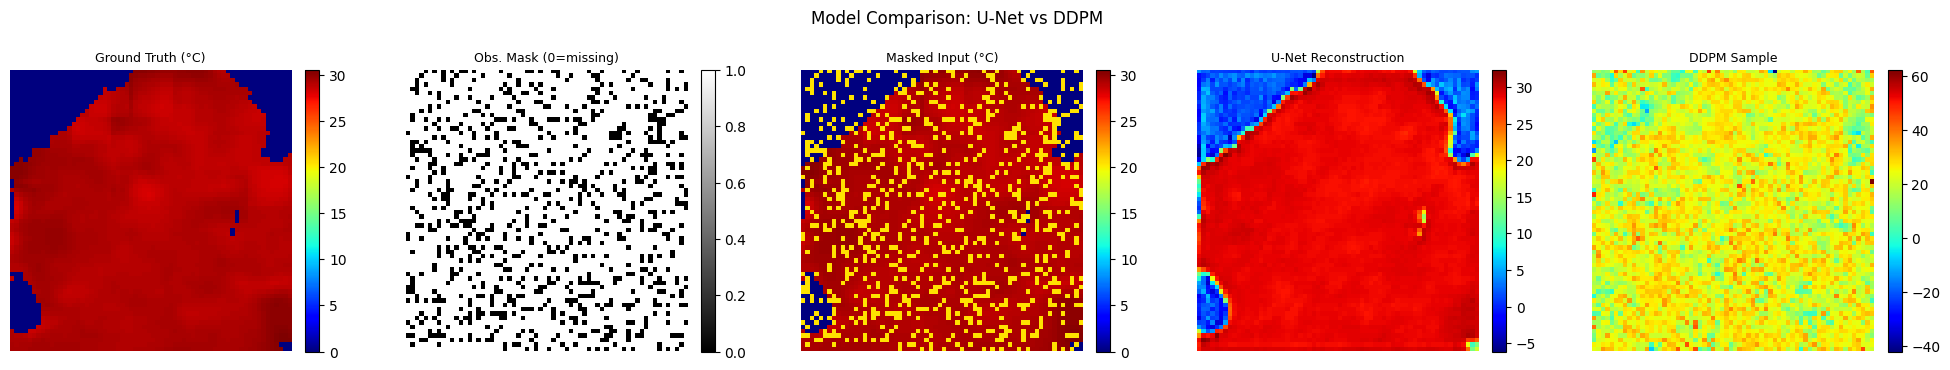

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — DDPM Reverse Sampling & Model Comparison
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def p_sample_step(
    x_t: torch.Tensor,
    m: torch.Tensor,
    c: torch.Tensor,
    t: torch.Tensor
) -> torch.Tensor:
    """One reverse diffusion step: predict x_{t-1} from x_t."""
    beta_t      = extract(BETAS,      t, x_t.shape)
    alpha_t     = extract(ALPHAS,     t, x_t.shape)
    alpha_bar_t = extract(ALPHAS_BAR, t, x_t.shape)
    eps_hat     = ddpm(x_t, m, c, t)
    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * eps_hat
    )
    if t.min() > 0:
        x_prev = mean + torch.sqrt(beta_t) * torch.randn_like(x_t)
    else:
        x_prev = mean    # no noise at final step
    return x_prev


@torch.no_grad()
def ddpm_sample(m: torch.Tensor, c: torch.Tensor, shape: tuple) -> torch.Tensor:
    """Full reverse diffusion: sample from Gaussian noise → SST patch."""
    x_t = torch.randn(shape, device=DEVICE)
    for step in reversed(range(DDPM_STEPS)):
        t = torch.full((m.size(0),), step, device=DEVICE, dtype=torch.long)
        x_t = p_sample_step(x_t, m, c, t)
    return x_t


# Compare U-Net vs DDPM on the same test patch
i  = np.random.randint(0, len(Xte))
xb = torch.from_numpy(Xte[i:i+1]).to(DEVICE)
mb = torch.from_numpy(Mte[i:i+1]).to(DEVICE)
cb = torch.from_numpy(Cte[i:i+1]).to(DEVICE)
yb = torch.from_numpy(Yte[i:i+1]).to(DEVICE)

# U-Net: MC mean
model.train(True)
preds    = [model(xb, mb, cb) for _ in range(MC_T)]
pm_unet  = torch.stack(preds, 0).mean(0)[0, 0].detach().cpu().numpy()

# DDPM: one stochastic sample
ddpm.eval()
pm_ddpm  = ddpm_sample(mb, cb, shape=yb.shape)[0, 0].detach().cpu().numpy()

gt_np   = yb[0, 0].detach().cpu().numpy()
mask_np = mb[0, 0].detach().cpu().numpy()
in_np   = xb[0, 0].detach().cpu().numpy()

fig, axs = plt.subplots(1, 5, figsize=(20, 3.5))
panels = [
    (denorm(gt_np),   'Ground Truth (°C)'),
    (mask_np,         'Obs. Mask (0=missing)'),
    (denorm(in_np),   'Masked Input (°C)'),
    (denorm(pm_unet), 'U-Net Reconstruction'),
    (denorm(pm_ddpm), 'DDPM Sample'),
]
cmaps = ['jet', 'gray', 'jet', 'jet', 'jet']
for ax, (data, title), cmap in zip(axs, panels, cmaps):
    im = ax.imshow(data, origin='lower', cmap=cmap)
    ax.set_title(title, fontsize=9); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle('Model Comparison: U-Net vs DDPM', fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/compare_unet_ddpm.png", dpi=200); plt.show()

Building climatology from 2010–2020...
(This downloads ~1.1 GB of OISST data — cached after first run)
Climatology built.

Analysing MHW for 2019...
  Total MHW days: 361
  Longest consecutive run (>20% area): 37 days
  Mean intensity: 0.73°C above threshold


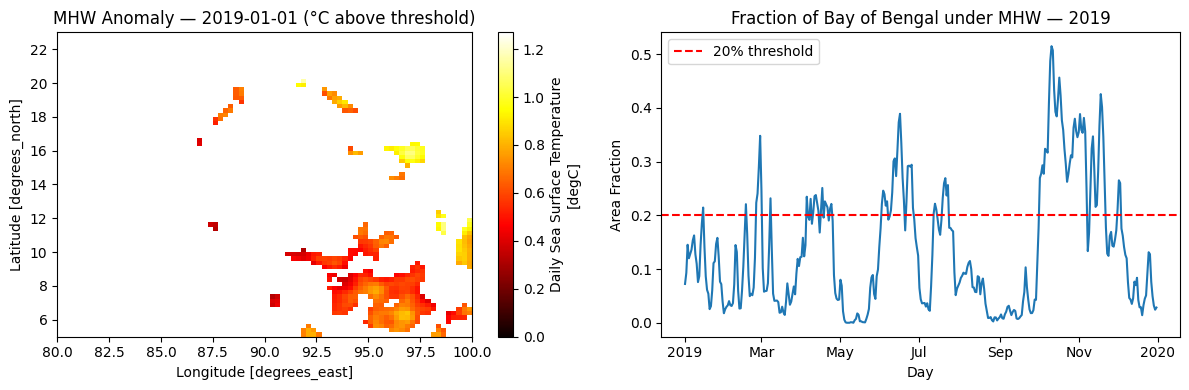

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — Climatology & Marine Heatwave Detection (Hobday et al., 2016)
# ─────────────────────────────────────────────────────────────────────────────
# MHW Definition (Hobday 2016):
#   A marine heatwave occurs when SST exceeds the 90th percentile of the
#   local climatology (2010–2020 baseline) for ≥5 consecutive days.
# We implement the spatial version: flag pixels exceeding the threshold.

BASE_YEARS = list(range(2010, 2021))
print(f"Building climatology from {BASE_YEARS[0]}–{BASE_YEARS[-1]}...")
print("(This downloads ~1.1 GB of OISST data — cached after first run)")

base_list = [open_subset_year(y) for y in BASE_YEARS]
clim_ds   = xr.concat(base_list, dim='time').sortby('time')

# 11-day centred rolling mean smooths the climatology
clim  = clim_ds['SST'].groupby('time.dayofyear').mean('time', skipna=True)
clim  = clim.rolling(dayofyear=11, center=True, min_periods=1).mean()

thresh = clim_ds['SST'].groupby('time.dayofyear').quantile(0.90, dim='time', skipna=True)
thresh = thresh.rolling(dayofyear=11, center=True, min_periods=1).mean()

print("Climatology built.")


def detect_mhw(ds_year: xr.Dataset, clim: xr.DataArray, thresh: xr.DataArray):
    """Detect marine heatwaves as SST anomalies exceeding the 90th percentile.

    Returns:
        mhw     : anomaly field masked where SST > threshold (MHW pixels only)
        anomaly : full SST anomaly relative to climatology
        thresh_match : threshold values matched to the year's day-of-year
    """
    da = ds_year['SST']
    if not np.issubdtype(da['time'].dtype, np.datetime64):
        da = xr.decode_cf(ds_year)['SST']
    doy          = da['time'].dt.dayofyear
    clim_match   = clim.sel(dayofyear=doy)
    thresh_match = thresh.sel(dayofyear=doy)
    anomaly      = da - clim_match
    mhw          = anomaly.where(da > thresh_match)   # NaN where no heatwave
    return mhw, anomaly, thresh_match


def longest_consecutive_run(binary_series):
    """Find longest run of consecutive True values (for MHW duration)."""
    best = cur = 0
    for v in binary_series:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best


print(f"\nAnalysing MHW for {YEAR_SELECT}...")
ds_y = open_subset_year(YEAR_SELECT)
mhw, anomaly, thresh_match = detect_mhw(ds_y, clim, thresh)

area_frac   = mhw.notnull().mean(dim=('lat', 'lon')).fillna(0.0)
total_days  = float((area_frac > 0).sum().item())
longest     = int(longest_consecutive_run((area_frac.values > 0.2).astype(int)))
mean_intens = float(mhw.mean(skipna=True).values)

print(f"  Total MHW days: {total_days:.0f}")
print(f"  Longest consecutive run (>20% area): {longest} days")
print(f"  Mean intensity: {mean_intens:.2f}°C above threshold")

# Plot first MHW event
if (area_frac.values > 0).any():
    first_idx  = int(np.argmax(area_frac.values > 0))
    first_date = pd.to_datetime(ds_y.time.values[first_idx]).strftime('%Y-%m-%d')
    fig, axes  = plt.subplots(1, 2, figsize=(12, 4))
    mhw.isel(time=first_idx).plot(ax=axes[0], cmap='hot', vmin=0)
    axes[0].set_title(f'MHW Anomaly — {first_date} (°C above threshold)')
    area_frac.plot(ax=axes[1])
    axes[1].axhline(0.2, color='red', linestyle='--', label='20% threshold')
    axes[1].set_title(f'Fraction of Bay of Bengal under MHW — {YEAR_SELECT}')
    axes[1].set_xlabel('Day'); axes[1].set_ylabel('Area Fraction'); axes[1].legend()
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/MHW_map_{YEAR_SELECT}.png", dpi=200); plt.show()
else:
    print(f"No MHW days detected in {YEAR_SELECT}.")

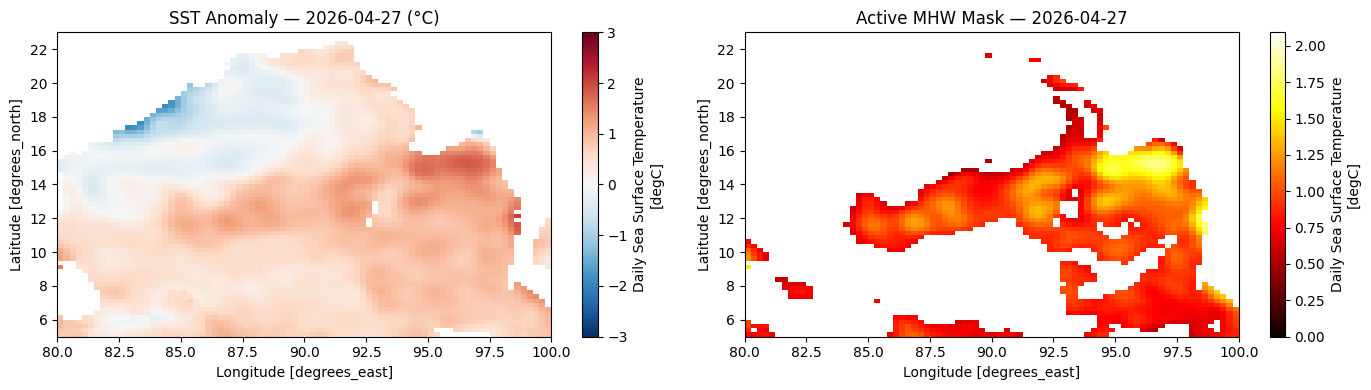

Present-day data processed: 2026-04-27


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 — Present-Day SST Anomaly & MHW Status (Optional)
# ─────────────────────────────────────────────────────────────────────────────

if USE_PRESENT_DAY:
    try:
        cur_year   = dt.date.today().year
        ds_today   = open_subset_year(cur_year)
        latest     = str(ds_today.time.values[-1])[:10]
        mhw_today, anomaly_today, _ = detect_mhw(ds_today, clim, thresh)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        anomaly_today.isel(time=-1).plot(ax=axes[0], cmap='RdBu_r', vmin=-3, vmax=3)
        axes[0].set_title(f'SST Anomaly — {latest} (°C)')
        mhw_today.isel(time=-1).plot(ax=axes[1], cmap='hot', vmin=0)
        axes[1].set_title(f'Active MHW Mask — {latest}')
        plt.tight_layout(); plt.savefig(f"{FIG_DIR}/SST_present_day.png", dpi=200); plt.show()
        print(f"Present-day data processed: {latest}")
    except Exception as e:
        print(f"Present-day step skipped: {e}")

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11 — Short-Range SST Forecast (3D CNN)
# ─────────────────────────────────────────────────────────────────────────────
# Input: 14 consecutive daily SST frames (T_in, H, W)
# Output: next-day SST prediction, rolled K times for K-day forecast
# Architecture: 3D CNN captures temporal + spatial patterns jointly

A      = arrn.values.astype('float32')   # (T, H, W) normalised
T_full, H, W = A.shape


def build_sequences(A: np.ndarray, T_in: int = 14):
    """Build sliding-window input/output pairs for the forecaster."""
    Xseq, Yt = [], []
    for t in range(T_in, len(A) - 1):
        Xseq.append(A[t - T_in:t])   # (T_in, H, W)
        Yt.append(A[t + 1])           # (H, W)
    if not Xseq:
        raise RuntimeError("Not enough days for sequences. Increase YEARS or reduce FCTX_DAYS.")
    Xseq = np.stack(Xseq)[:, None, ...]   # (N, 1, T_in, H, W)
    Yt   = np.stack(Yt)[:, None, ...]     # (N, 1, H, W)
    return Xseq.astype('float32'), Yt.astype('float32')


Xseq, Yseq = build_sequences(A, T_in=FCTX_DAYS)
N      = len(Xseq)
idx    = np.arange(N)
rng.shuffle(idx)
ntr_s  = int(0.8 * N)
tr_idx_s, va_idx_s = idx[:ntr_s], idx[ntr_s:]

Xtr_s, Ytr_s = Xseq[tr_idx_s], Yseq[tr_idx_s]
Xva_s, Yva_s = Xseq[va_idx_s], Yseq[va_idx_s]
print(f"Sequences — Train: {len(Xtr_s)} | Val: {len(Yva_s)}")


class CNN3DForecaster(nn.Module):
    """
    3D Convolutional Forecaster for short-range SST prediction.

    3D convolutions process the time dimension jointly with spatial dimensions,
    learning spatiotemporal patterns like SST advection and heat accumulation.
    """
    def __init__(self, T_in: int = 14):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv3d(1,  8, kernel_size=(3, 3, 3), padding=(1, 1, 1)), nn.ReLU(), nn.BatchNorm3d(8),
            nn.Conv3d(8, 16, kernel_size=(3, 3, 3), padding=(1, 1, 1)), nn.ReLU(), nn.BatchNorm3d(16),
            nn.Conv3d(16,16, kernel_size=(3, 3, 3), padding=(1, 1, 1)), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Conv3d(16, 8, kernel_size=(T_in, 1, 1)), nn.ReLU(),
            nn.Conv3d(8,  1, kernel_size=1)
        )
    def forward(self, x):   # x: (B, 1, T_in, H, W)
        return self.head(self.body(x)).squeeze(2)  # (B, 1, H, W)


f_model = CNN3DForecaster(T_in=FCTX_DAYS).to(DEVICE)
optf    = torch.optim.AdamW(f_model.parameters(), lr=1e-3, weight_decay=1e-5)


class SeqDataset(Dataset):
    def __init__(self, X, Y): self.X, self.Y = X, Y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return torch.from_numpy(self.X[i]), torch.from_numpy(self.Y[i])


tr_dl_s = DataLoader(SeqDataset(Xtr_s, Ytr_s), batch_size=F_BATCH, shuffle=True)
va_dl_s = DataLoader(SeqDataset(Xva_s, Yva_s), batch_size=F_BATCH, shuffle=False)


def run_epoch_fore(dl, train: bool = True) -> float:
    f_model.train(train)
    total, n = 0.0, 0
    for xb, yb in dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        pred   = f_model(xb)
        loss   = F.l1_loss(pred, yb) + 0.2 * F.mse_loss(pred, yb)
        if train:
            optf.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(f_model.parameters(), 1.0)
            optf.step()
        total += loss.item() * len(xb); n += len(xb)
    return total / max(n, 1)


print("\nTraining 3D CNN Forecaster...")
bestf, bestfw = float('inf'), None
for ep in range(1, F_EPOCHS + 1):
    tr = run_epoch_fore(tr_dl_s, True)
    va = run_epoch_fore(va_dl_s, False)
    print(f"  Epoch {ep:02d}/{F_EPOCHS} | train={tr:.4f} | val={va:.4f}")
    if va < bestf:
        bestf = va
        bestfw = {k: v.detach().cpu().clone() for k, v in f_model.state_dict().items()}
f_model.load_state_dict(bestfw)
print(f"Best forecast val loss: {bestf:.4f}")

Sequences — Train: 280 | Val: 70

Training 3D CNN Forecaster...
  Epoch 01/3 | train=0.5198 | val=0.5659
  Epoch 02/3 | train=0.2058 | val=0.4695
  Epoch 03/3 | train=0.1092 | val=0.2891
Best forecast val loss: 0.2891


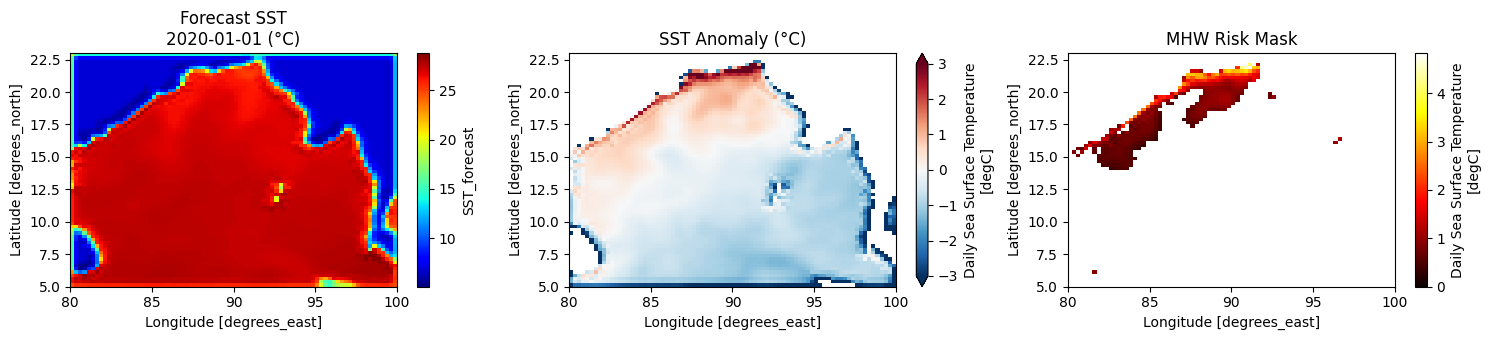

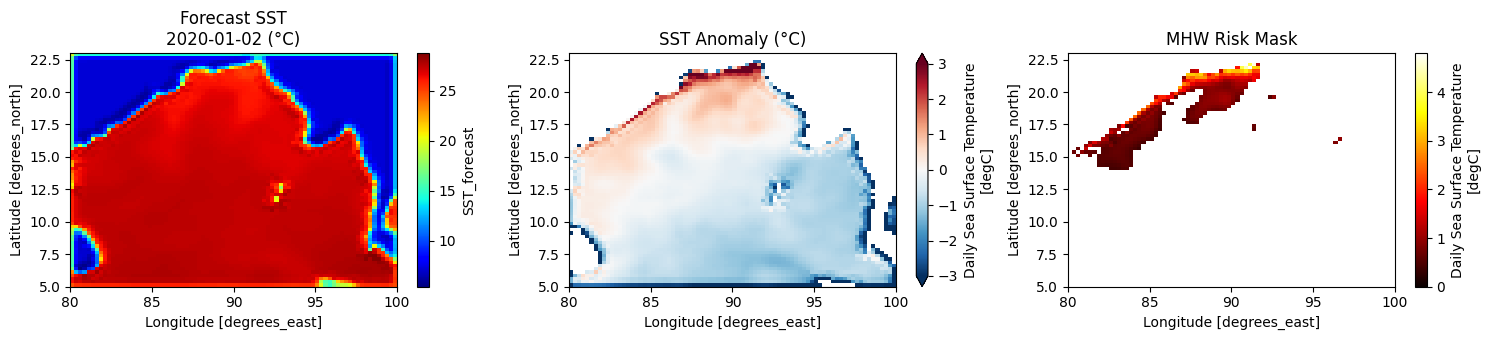

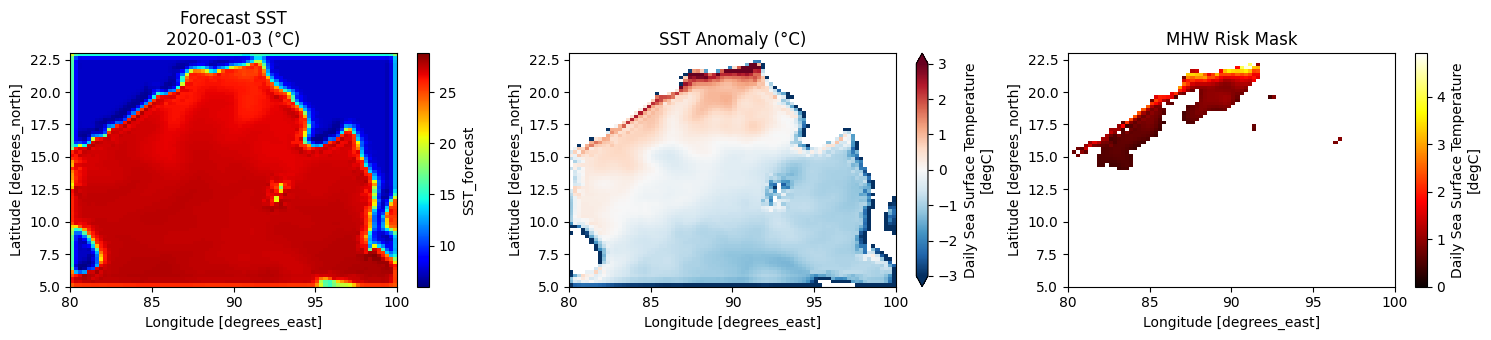


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
ALL OUTPUTS SAVED:
  Figures → /content/figs/
  MHW forecast summary → /content/figs/forecast_MHW_summary_2019.csv

Forecast MHW Area Fractions:
      date  mhw_area_fraction
2020-01-01           0.072917
2020-01-02           0.072743
2020-01-03           0.073264


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12 — Multi-Day Forecast & MHW Projection
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def forecast_multi(
    model: nn.Module,
    A_last: np.ndarray,
    steps: int = 3,
    T_in: int = FCTX_DAYS
) -> np.ndarray:
    """Auto-regressive multi-step forecast: each prediction feeds the next step."""
    preds = []
    seq   = A_last.copy()   # (T_in, H, W)
    for _ in range(steps):
        x    = torch.from_numpy(seq[None, None, ...]).to(DEVICE)
        yhat = model(x).cpu().numpy()[0, 0]
        preds.append(yhat)
        seq  = np.concatenate([seq[1:], yhat[None, ...]], axis=0)  # slide window
    return np.array(preds)   # (steps, H, W)


# Use last FCTX_DAYS from YEAR_SELECT as context
ds_y   = open_subset_year(YEAR_SELECT)
sst_y  = ds_y['SST'].astype('float32').fillna(0.0).clip(min=-2.0, max=35.0)
A_year = ((sst_y - mu) / (sigma + 1e-6)).values.astype('float32')

if A_year.shape[0] < FCTX_DAYS + 1:
    raise RuntimeError(f"Year {YEAR_SELECT} has fewer than {FCTX_DAYS + 1} days. Reduce FCTX_DAYS.")

last_seq  = A_year[-FCTX_DAYS:]                              # (14, H, W)
preds_n   = forecast_multi(f_model, last_seq, steps=FUTURE_DAYS)
preds_c   = denorm(preds_n)                                  # convert back to °C

last_date    = pd.to_datetime(ds_y.time.values[-1])
future_times = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FUTURE_DAYS, freq='D')

pred_da = xr.DataArray(
    preds_c,
    coords={'time': future_times, 'lat': ds_y['lat'], 'lon': ds_y['lon']},
    dims=('time', 'lat', 'lon'),
    name='SST_forecast'
)

# Apply Hobday MHW detection to each forecast day
mhw_list, anom_list = [], []
for tt in range(FUTURE_DAYS):
    date   = future_times[tt]
    clim_d = clim.sel(dayofyear=int(date.dayofyear), method='nearest')
    thr_d  = thresh.sel(dayofyear=int(date.dayofyear), method='nearest')
    sst_d  = pred_da.isel(time=tt)
    anom_d = sst_d - clim_d
    mhw_list.append(anom_d.where(sst_d > thr_d))
    anom_list.append(anom_d)

anom_future = xr.concat(anom_list, dim='time').assign_coords(time=future_times)
mhw_future  = xr.concat(mhw_list,  dim='time').assign_coords(time=future_times)

# Plot each forecast day
for i, t in enumerate(future_times):
    fig = plt.figure(figsize=(15, 3.5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)
    ax1 = fig.add_subplot(gs[0]); ax2 = fig.add_subplot(gs[1]); ax3 = fig.add_subplot(gs[2])
    pred_da.isel(time=i).plot(ax=ax1, cmap='jet');         ax1.set_title(f'Forecast SST\n{t.date()} (°C)')
    anom_future.isel(time=i).plot(ax=ax2, cmap='RdBu_r', vmin=-3, vmax=3); ax2.set_title('SST Anomaly (°C)')
    mhw_future.isel(time=i).plot(ax=ax3, cmap='hot', vmin=0);  ax3.set_title('MHW Risk Mask')
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/forecast_{YEAR_SELECT}_day{i+1}.png", dpi=200); plt.show()

# Summary CSV
area_frac = mhw_future.notnull().mean(dim=('lat', 'lon')).fillna(0.0).to_pandas()
summary   = pd.DataFrame({'date': future_times, 'mhw_area_fraction': area_frac.values})
summary.to_csv(f"{FIG_DIR}/forecast_MHW_summary_{YEAR_SELECT}.csv", index=False)

print("\n=" * 50)
print("ALL OUTPUTS SAVED:")
print(f"  Figures → {FIG_DIR}/")
print(f"  MHW forecast summary → {FIG_DIR}/forecast_MHW_summary_{YEAR_SELECT}.csv")
print("="  * 50)
print("\nForecast MHW Area Fractions:")
print(summary.to_string(index=False))